In [59]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import seaborn as sns
import matplotlib.pyplot as plt

# Set global Seaborn style
sns.set_theme(
    style='whitegrid',
    context='paper',
    font='DejaVu Sans',
)

%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from common.consts import res_colors
from common.utils import load_lambda_grid, collect_df

data_dir = repo_root / "data"
mfpt_grid_pkl = data_dir / "mfpt_all_thresholds-new-ref.pkl"
mfpt_default_pkl = data_dir / "mfpt-pace=25000-new-ref.pkl"
tm_csv = data_dir / "Tm.csv"
lambda_cache = data_dir / "hlda_lambda_grid.pkl"

with open(mfpt_grid_pkl, "rb") as f:
    mfpt_tables = pickle.load(f)
mfpt_thresholds = sorted(mfpt_tables.keys())

with open(mfpt_default_pkl, "rb") as f:
    mfpt_all = pickle.load(f)

tm = pd.read_csv(tm_csv, index_col="Mutant")
tm["Tm"] = pd.to_numeric(tm["Tm"], errors="coerce")
tm["abs_dTm"] = abs(tm["Tm"] - tm.loc["WT", "Tm"])

lambda_grid = load_lambda_grid(cache_path=lambda_cache, force=False)
lambda_grid.head()


,Mutant,tF,tU,lambda,n_desc,nF,nU,var_F_diag,var_U_diag,mean_rmsd_F,mean_rmsd_U,weights,res_weights
0,D2A,0.18,0.30,5955.283188,21,8861,91951,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021822002644914233, 0.034387766655950155, 0...",0.161013,0.658883,"{'d03': 0.27, 'd04': -0.38, 'd05': 0.42, 'd06'...","[1.56, 0.76, 0.75, 0.72, 0.94, 1.0, 0.43, 0.79..."
1,D2A,0.18,0.35,6036.763512,21,8861,91356,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021914678202689043, 0.034590364267731204, 0...",0.161013,0.661036,"{'d03': 0.27, 'd04': -0.38, 'd05': 0.42, 'd06'...","[1.56, 0.76, 0.75, 0.72, 0.94, 1.0, 0.43, 0.79..."
2,D2A,0.18,0.41,6464.830477,21,8861,88358,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022499551728532702, 0.03570512795072451, 0....",0.161013,0.670334,"{'d03': 0.28, 'd04': -0.38, 'd05': 0.41, 'd06'...","[1.56, 0.75, 0.75, 0.73, 0.93, 0.98, 0.44, 0.7..."
3,D2A,0.18,0.46,7615.077001,22,8861,86336,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022895281380262797, 0.03646222800497214, 0....",0.161013,0.675939,"{'d03': 0.14, 'd04': -0.39, 'd05': 0.54, 'd06'...","[1.6, 0.77, 0.7, 0.38, 0.88, 1.4, 0.48, 0.74, ..."
4,D2A,0.18,0.52,6924.540912,21,8861,84109,"[0.0008478472743267516, 0.0011329781051374278,...","[0.023076225309800618, 0.036911968254067555, 0...",0.161013,0.680653,"{'d03': 0.28, 'd04': -0.37, 'd05': 0.41, 'd06'...","[1.58, 0.76, 0.76, 0.73, 0.93, 0.98, 0.44, 0.8..."


In [61]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap="rocket_r"):
    P = df.pivot(index="tF", columns="tU", values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading="flat"
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{val:.2f}", ha="center", va="center", fontsize=6)

    ax.set_xlabel("tU")
    ax.set_ylabel("tF")
    ax.set_title(title, fontsize=9)
    return im


def add_wt_point(ax, lambda_df, tF, tU):
    wt_rows = lambda_df[(lambda_df["Mutant"] == "WT") & np.isclose(lambda_df["tF"], tF) & np.isclose(lambda_df["tU"], tU)]
    if wt_rows.empty:
        return
    x_wt = float(wt_rows["lambda"].iloc[0])
    ax.scatter([x_wt], [0.0], s=90, marker="*", color="red", edgecolor="black", zorder=5)
    y_min, y_max = ax.get_ylim()
    dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)
    ax.text(x_wt, dy, "WT", ha="center", va="bottom", fontsize=8, color="red", weight="bold")


def scatter_with_labels_ax(ax, df, x_col, y_col, label_col, title, xlab, ylab, rho, tF, tU, add_wt=True, corr_label="|ρ|"):
    if not df.empty:
        y_min, y_max = df[y_col].min(), df[y_col].max()
        dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)
        for _, row in df.iterrows():
            label = str(row[label_col])
            x = row[x_col]
            y = row[y_col]
            color = res_colors.get(int(row.get("residue_idx", np.nan)), "black")
            ax.scatter([x], [y], color=color, alpha=0.85)
            ax.text(x, y + dy, label, fontsize=6.5, ha="center", va="bottom", alpha=0.9)

    if add_wt:
        add_wt_point(ax, lambda_grid, tF, tU)

    ax.set_title(f"{title} {corr_label}={rho:.2f}, n={len(df)}, tF={tF:.2f}, tU={tU:.2f}", fontsize=9)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)


def mfpt_table_to_log_ratio(df_raw):
    if "Mutant" not in df_raw.columns:
        df = df_raw.rename_axis("Mutant").reset_index()
    else:
        df = df_raw.copy()
    df["Mutant"] = df["Mutant"].astype(str).str.strip()
    df["MFPT"] = df["mfpt"] / 1e6
    mfpt_wt = df.loc[df["Mutant"] == "WT", "MFPT"].iloc[0]
    df["log_mfpt_ratio"] = np.log(mfpt_wt / df["MFPT"])
    return df[["Mutant", "log_mfpt_ratio"]]


In [62]:
# Require residue weights in the cached grid
if 'res_weights' not in lambda_grid.columns:
    raise ValueError('Missing res_weights in hlda_lambda_grid.pkl; rebuild with weights.')


In [ ]:
# skip_short = {'P3R', 'Y0R'}
skip_short={}
# lambda_grid = lambda_grid[~lambda_grid['Mutant'].isin(skip_short)]


/tmp/ipykernel_37922/3215368244.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_37922/3215368244.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_37922/3215368244.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping colum

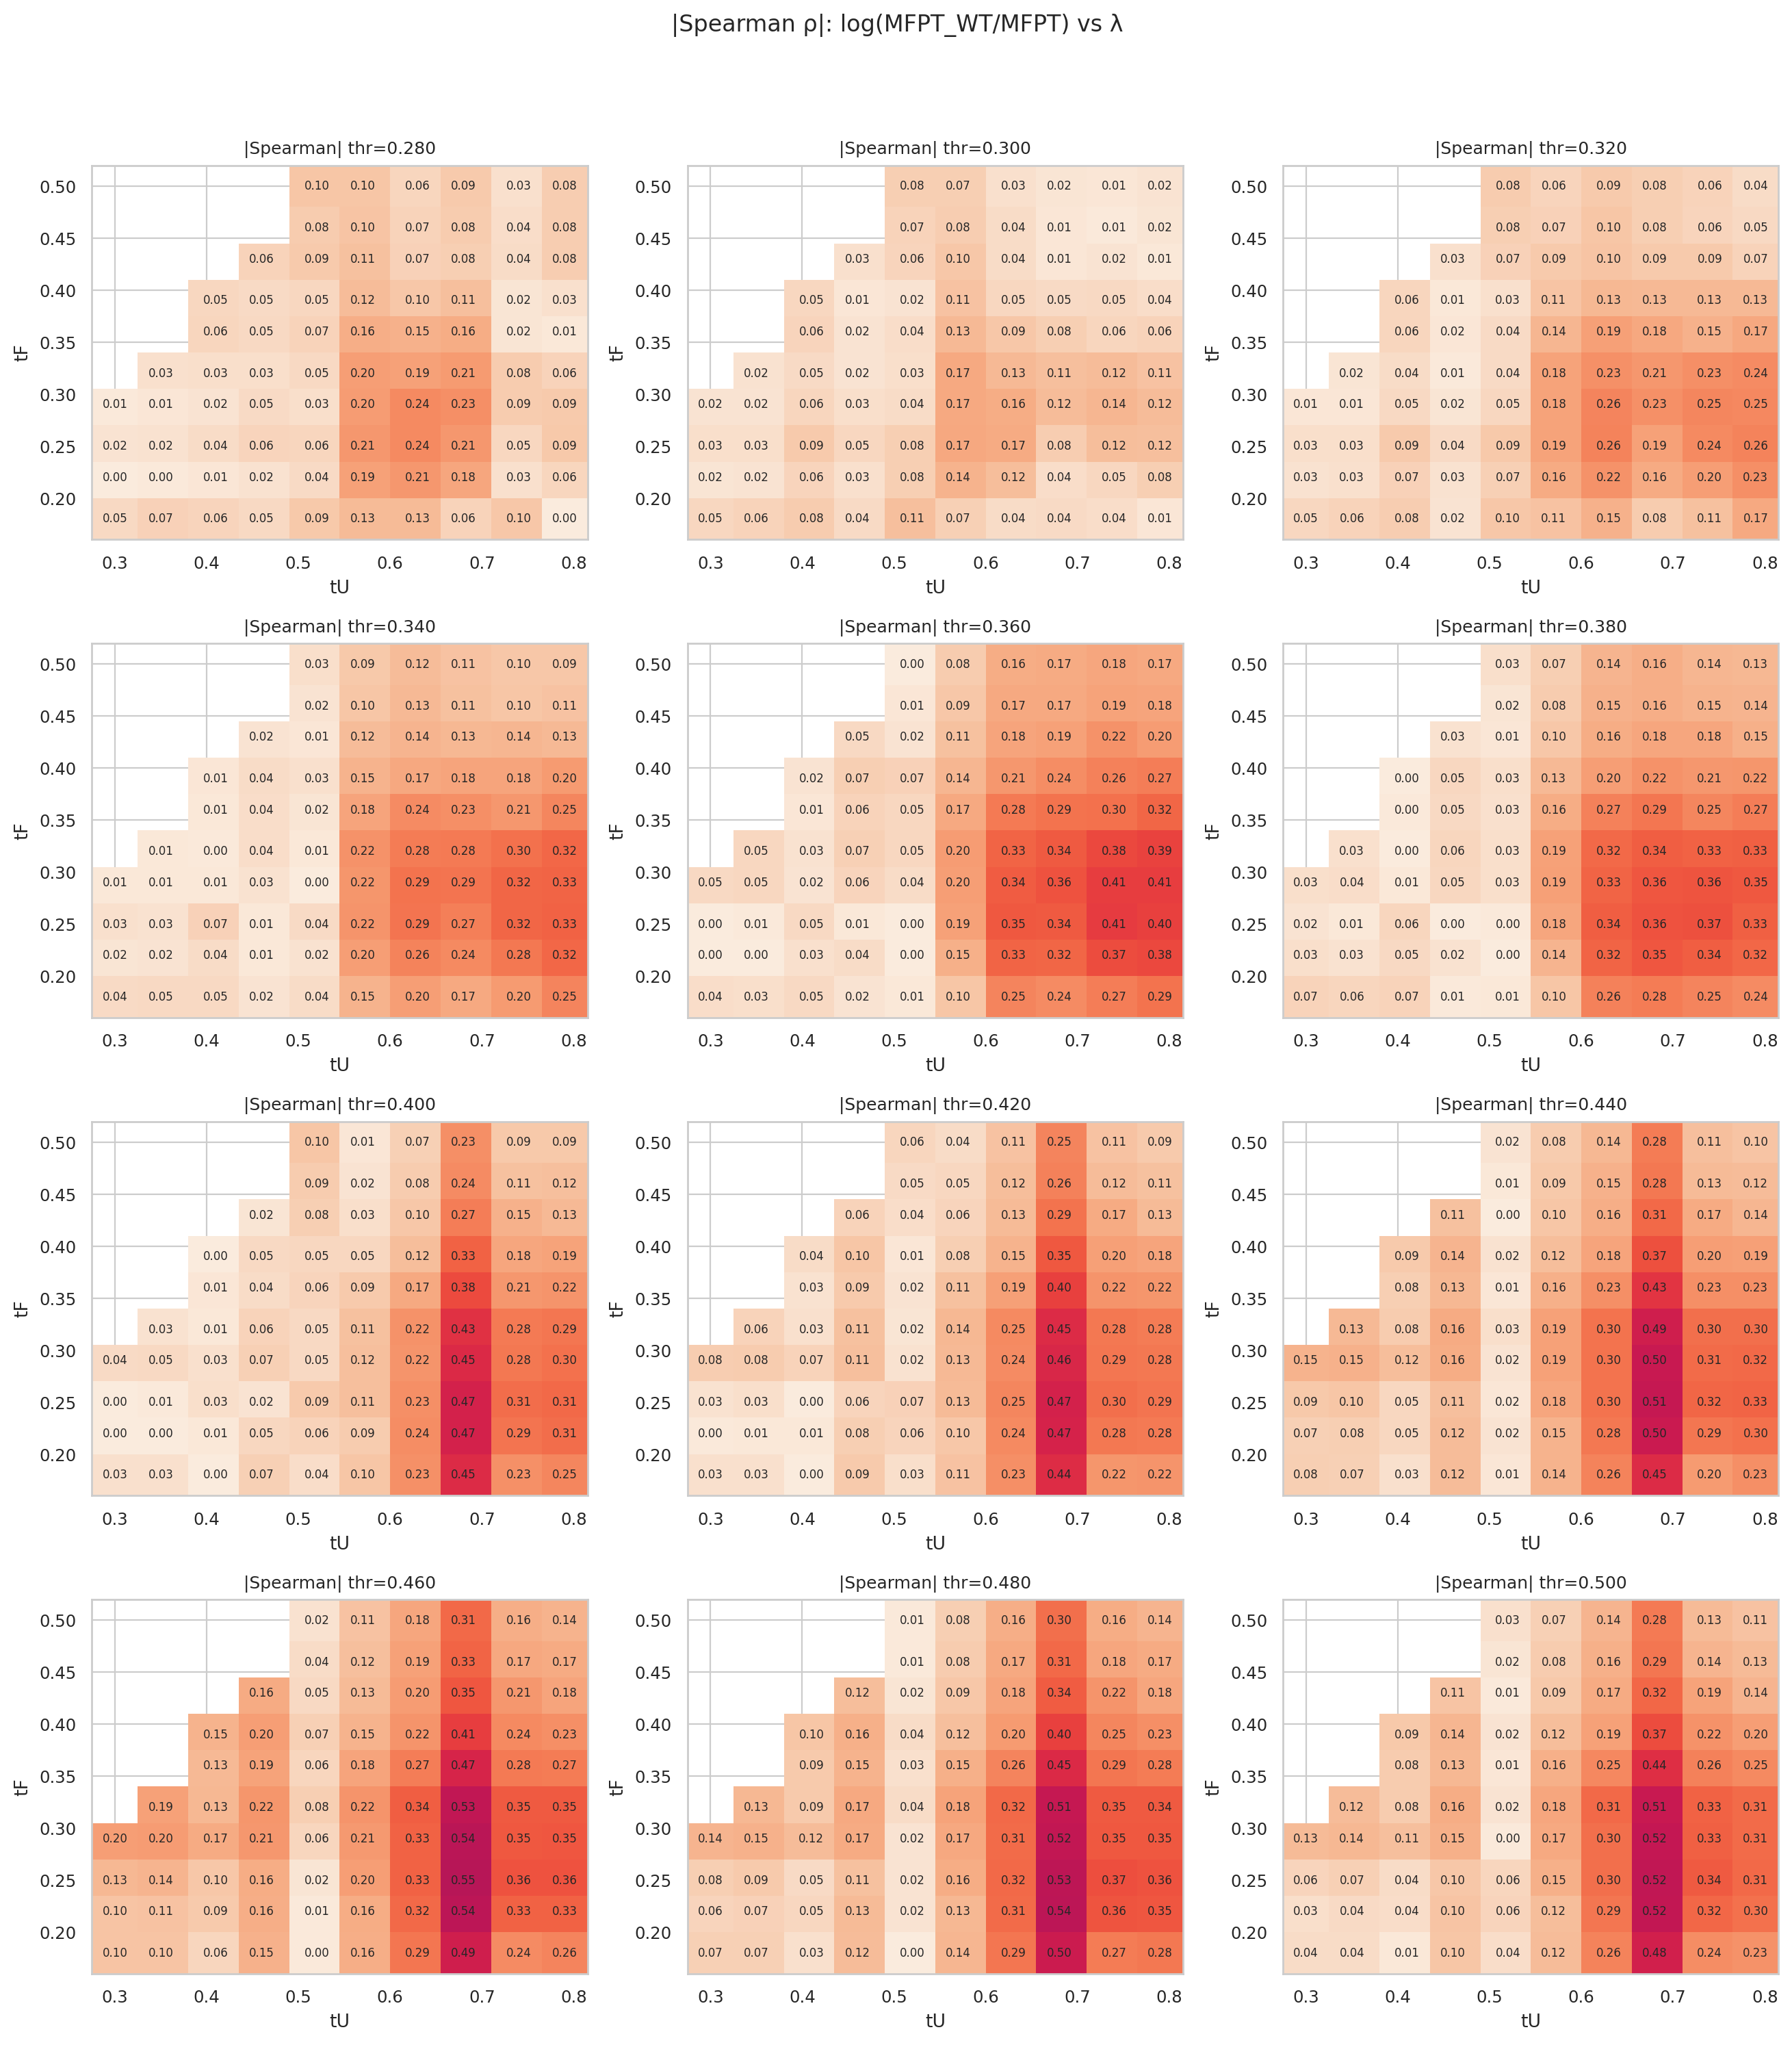

,mfpt_threshold,tF,tU,rho_spear_abs,n
0,0.28,0.25,0.63,0.243717,37
1,0.30,0.25,0.57,0.174964,37
2,0.32,0.25,0.63,0.259128,37
3,0.34,0.25,0.79,0.330251,37
4,0.36,0.25,0.74,0.407065,37
5,0.38,0.25,0.74,0.365102,37
6,0.40,0.25,0.68,0.473921,37
7,0.42,0.25,0.68,0.474158,37
8,0.44,0.25,0.68,0.513514,37
9,0.46,0.25,0.68,0.548601,37


In [65]:
mfpt_results = []

for thr in mfpt_thresholds:
    df_mfpt = mfpt_table_to_log_ratio(mfpt_tables[thr])
    merged = lambda_grid.merge(df_mfpt, on='Mutant', how='left')

    corrs = (
        merged.dropna(subset=['lambda', 'log_mfpt_ratio'])
        .groupby(['tF', 'tU'])
        .apply(lambda g: pd.Series({
            'rho_spear': g['lambda'].corr(g['log_mfpt_ratio'], method='spearman'),
            'rho_spear_abs': abs(g['lambda'].corr(g['log_mfpt_ratio'], method='spearman')),
            'n': len(g),
        }))
        .reset_index()
    )

    best_row = corrs.loc[corrs['rho_spear_abs'].idxmax()] if not corrs.empty else None
    mfpt_results.append({'threshold': thr, 'corrs': corrs, 'best': best_row})

ncols = min(3, len(mfpt_results) if mfpt_results else 1)
nrows = int(np.ceil(len(mfpt_results) / ncols)) if mfpt_results else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
for ax, res in zip(axes.ravel(), mfpt_results):
    df = res['corrs'].rename(columns={'rho_spear_abs': 'val'})
    plot_heatmap_in_ax(ax, df, 'val', title=f"|Spearman| thr={res['threshold']:.3f}", vmin=0, vmax=1)
for ax in axes.ravel()[len(mfpt_results):]:
    ax.axis('off')
fig.suptitle('|Spearman ρ|: log(MFPT_WT/MFPT) vs λ', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

best_mfpt_df = pd.DataFrame([
    {
        'mfpt_threshold': res['threshold'],
        'tF': float(res['best']['tF']) if res['best'] is not None else np.nan,
        'tU': float(res['best']['tU']) if res['best'] is not None else np.nan,
        'rho_spear_abs': float(res['best']['rho_spear_abs']) if res['best'] is not None else np.nan,
        'n': int(res['best']['n']) if res['best'] is not None else 0,
    }
    for res in mfpt_results
])
best_mfpt_path = data_dir / 'hlda_best_thresholds.csv'
best_mfpt_df.to_csv(best_mfpt_path, index=False)

best_mfpt_df


In [66]:
if best_mfpt_df.empty or best_mfpt_df['rho_spear_abs'].isna().all():
    raise ValueError('No MFPT correlations found; run previous cell first.')

best_idx = best_mfpt_df['rho_spear_abs'].astype(float).fillna(-np.inf).idxmax()
row_best = best_mfpt_df.loc[best_idx]
tF_best = float(row_best['tF'])
tU_best = float(row_best['tU'])
mfpt_thr_best = float(row_best['mfpt_threshold'])
rho_s_best = float(row_best['rho_spear_abs']) if not np.isnan(row_best['rho_spear_abs']) else np.nan
print(f"Using tF={tF_best:.2f}, tU={tU_best:.2f} (from MFPT thr={mfpt_thr_best:.3f}), |ρ_s|={rho_s_best:.2f}")

mfpt_threshold_options = [float(x) for x in sorted(mfpt_all['chignolin'].keys(), key=float)]
mfpt_threshold_for_table = mfpt_thr_best if any(np.isclose(mfpt_thr_best, opt) for opt in mfpt_threshold_options) else mfpt_threshold_options[0]

summary_df = collect_df(
    False,
    mfpt_all,
    mfpt_threshold_for_table,
    tF=tF_best,
    tU=tU_best,
    lambda_df=lambda_grid,
    skip_short=skip_short,
    quiet=True,
)
wt_mfpt = float(summary_df.loc['WT', 'mfpt'])
summary_df['log_mfpt_ratio'] = np.log(wt_mfpt / summary_df['mfpt'])
summary_path = data_dir / f"hlda_summary_tF={tF_best:.2f}_tU={tU_best:.2f}.csv"
summary_df.to_csv(summary_path)
summary_df[['lambda', 'abs_dvar_mean', 'abs_dTm', 'log_mfpt_ratio']].head()



Using tF=0.25, tU=0.68 (from MFPT thr=0.460), |ρ_s|=0.55


,lambda,abs_dvar_mean,abs_dTm,log_mfpt_ratio
short,,,,
WT,11794.154986,0.000000,0.0,0.000000
D2A,9423.731569,0.004700,13.0,0.228221
D2C,22317.045873,0.003569,28.0,-1.550486
D2M,15809.779912,0.005902,21.0,-1.131893
D2N,20749.460441,0.002812,13.0,-0.284662


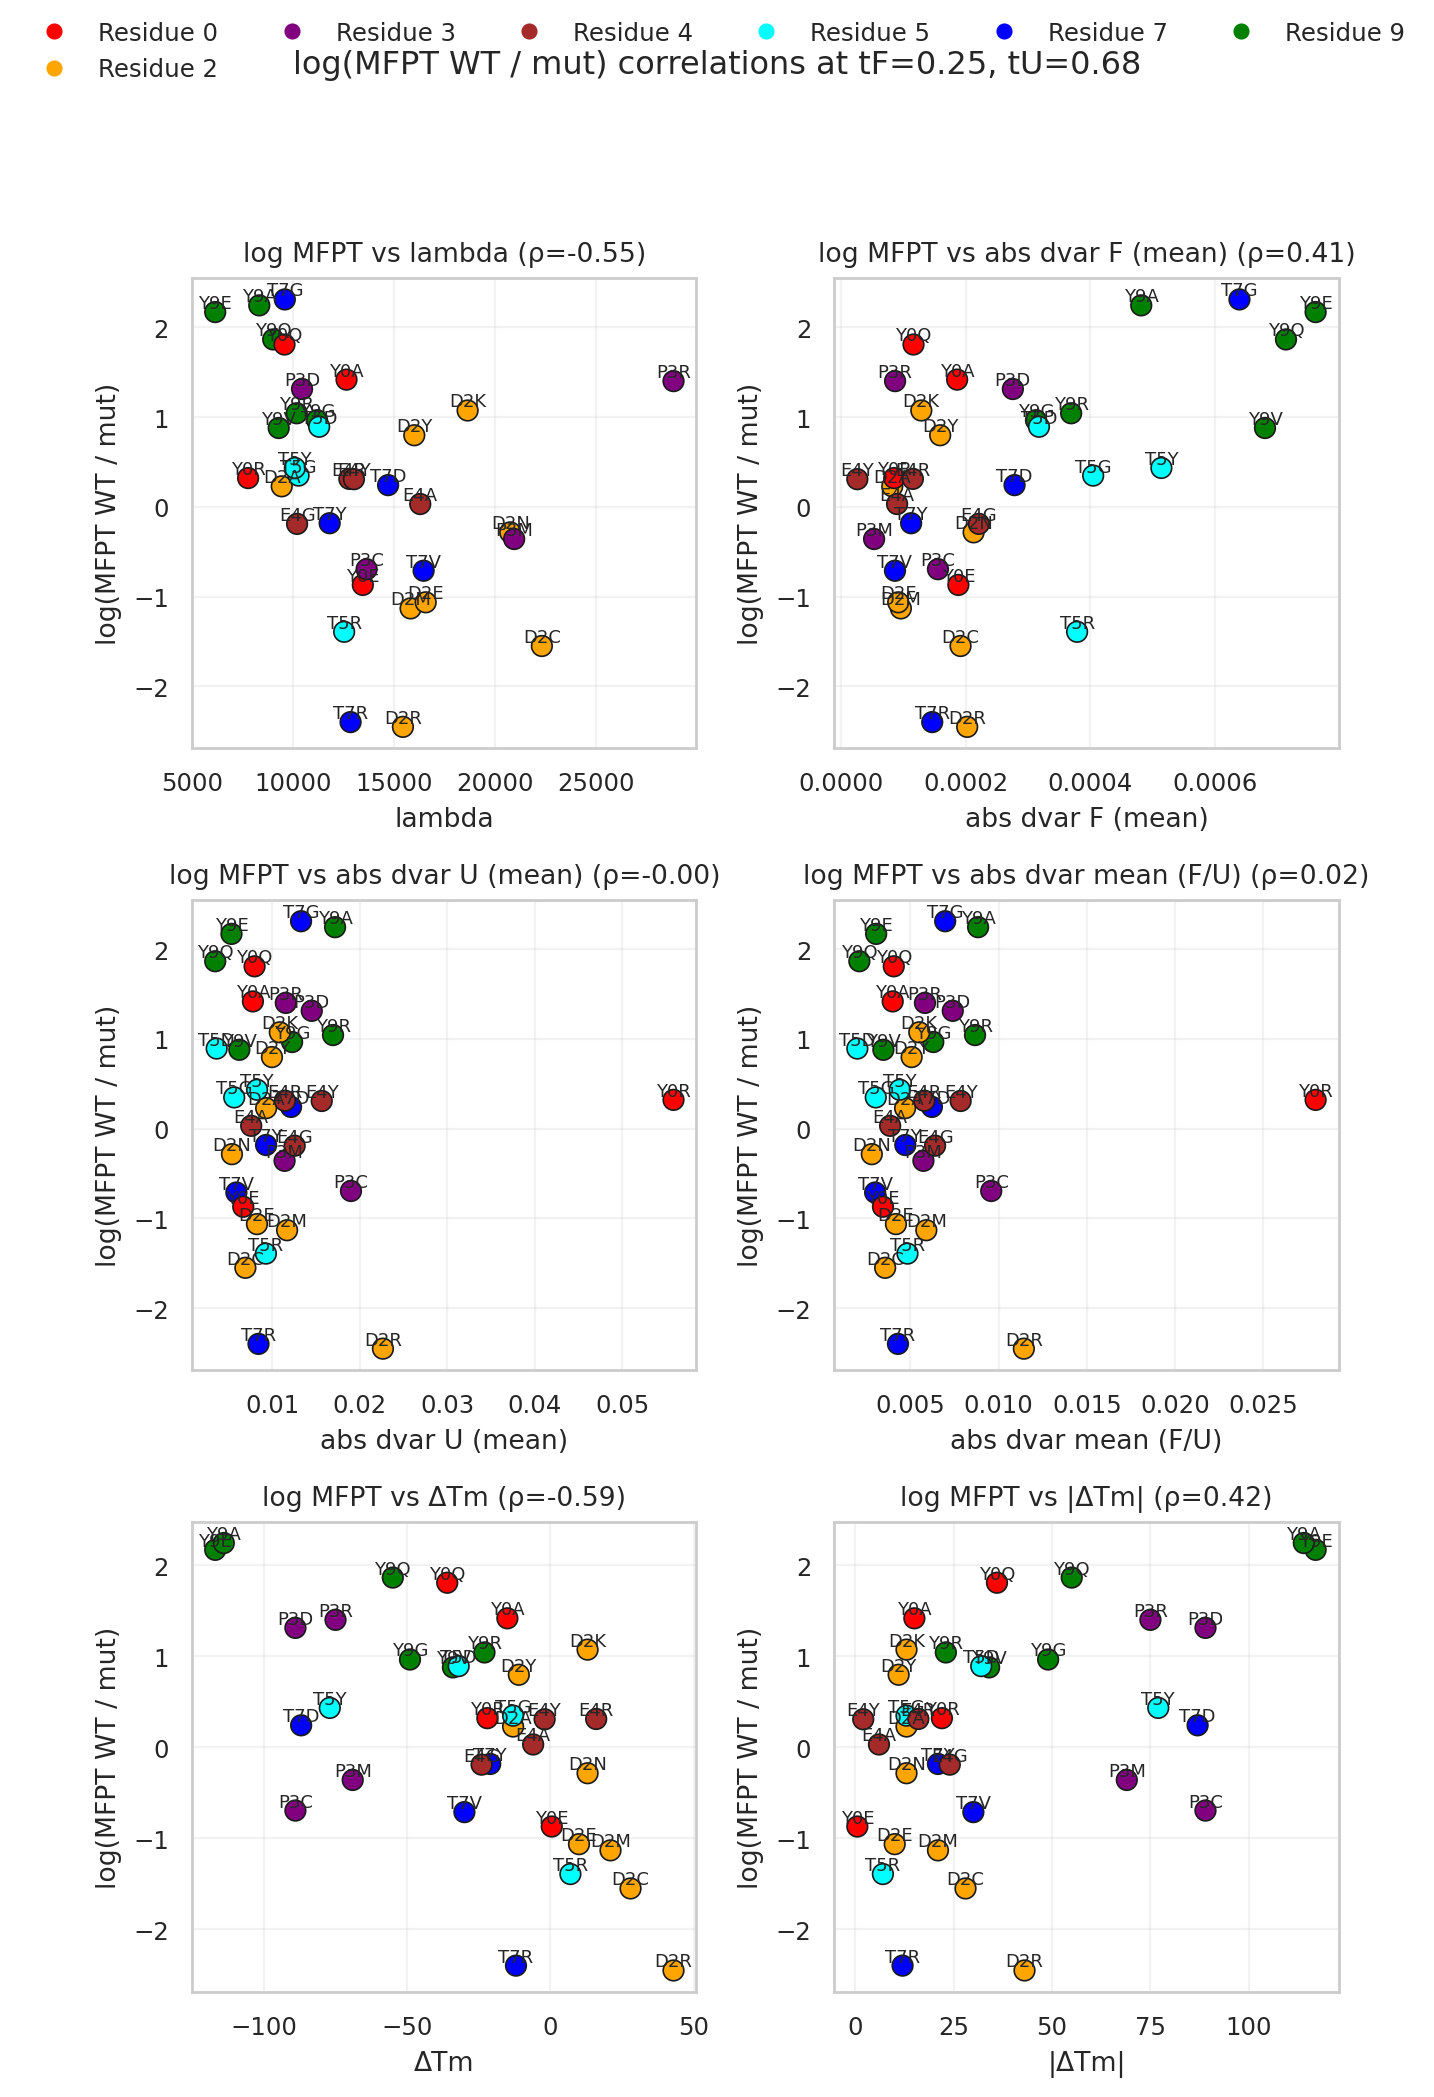

,feature,spearman,n
0,lambda,-0.547059,35
1,abs dvar F (mean),0.409244,35
2,abs dvar U (mean),-0.002521,35
3,abs dvar mean (F/U),0.023529,35
4,ΔTm,-0.590663,34
5,|ΔTm|,0.420401,34


In [67]:
corr_targets = [
    ('lambda', 'lambda'),
    ('abs_dvar_F', 'abs dvar F (mean)'),
    ('abs_dvar_U', 'abs dvar U (mean)'),
    ('abs_dvar_mean', 'abs dvar mean (F/U)'),
    ('dTm', 'ΔTm'),
    ('abs_dTm', '|ΔTm|'),
]

ncols = 2
nrows = int(np.ceil(len(corr_targets) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5, 3.5 * nrows), squeeze=False)

corr_rows = []

for (x_col, label), ax in zip(corr_targets, axes.ravel()):
    sub = summary_df.dropna(subset=[x_col, 'log_mfpt_ratio', 'residue_idx']).copy()
    if sub.empty:
        ax.axis('off')
        continue
    palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
    sns.scatterplot(data=sub, x=x_col, y='log_mfpt_ratio', hue='residue_idx', palette=palette, s=55, edgecolor='k', linewidth=0.6, ax=ax, legend=False)
    for name, row in sub.iterrows():
        ax.text(row[x_col], row['log_mfpt_ratio'], name, fontsize=6.5, ha='center', va='bottom')
    rho_s = sub[x_col].corr(sub['log_mfpt_ratio'], method='spearman')
    corr_rows.append({
        'feature': label,
        'spearman': rho_s,
        'n': len(sub)
    })
    ax.set_title(f"log MFPT vs {label} (ρ={rho_s:.2f})")
    ax.set_xlabel(label)
    ax.set_ylabel('log(MFPT WT / mut)')
    ax.grid(True, alpha=0.25)

for ax in axes.ravel()[len(corr_targets):]:
    ax.axis('off')

handles = [Line2D([0], [0], marker='o', linestyle='', color=res_colors[k], label=f"Residue {k}") for k in sorted(res_colors.keys())]
fig.legend(handles=handles, loc='upper center', ncol=min(6, len(handles)), frameon=False)
fig.suptitle(f"log(MFPT WT / mut) correlations at tF={tF_best:.2f}, tU={tU_best:.2f}")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

corr_df = pd.DataFrame(corr_rows)
corr_df



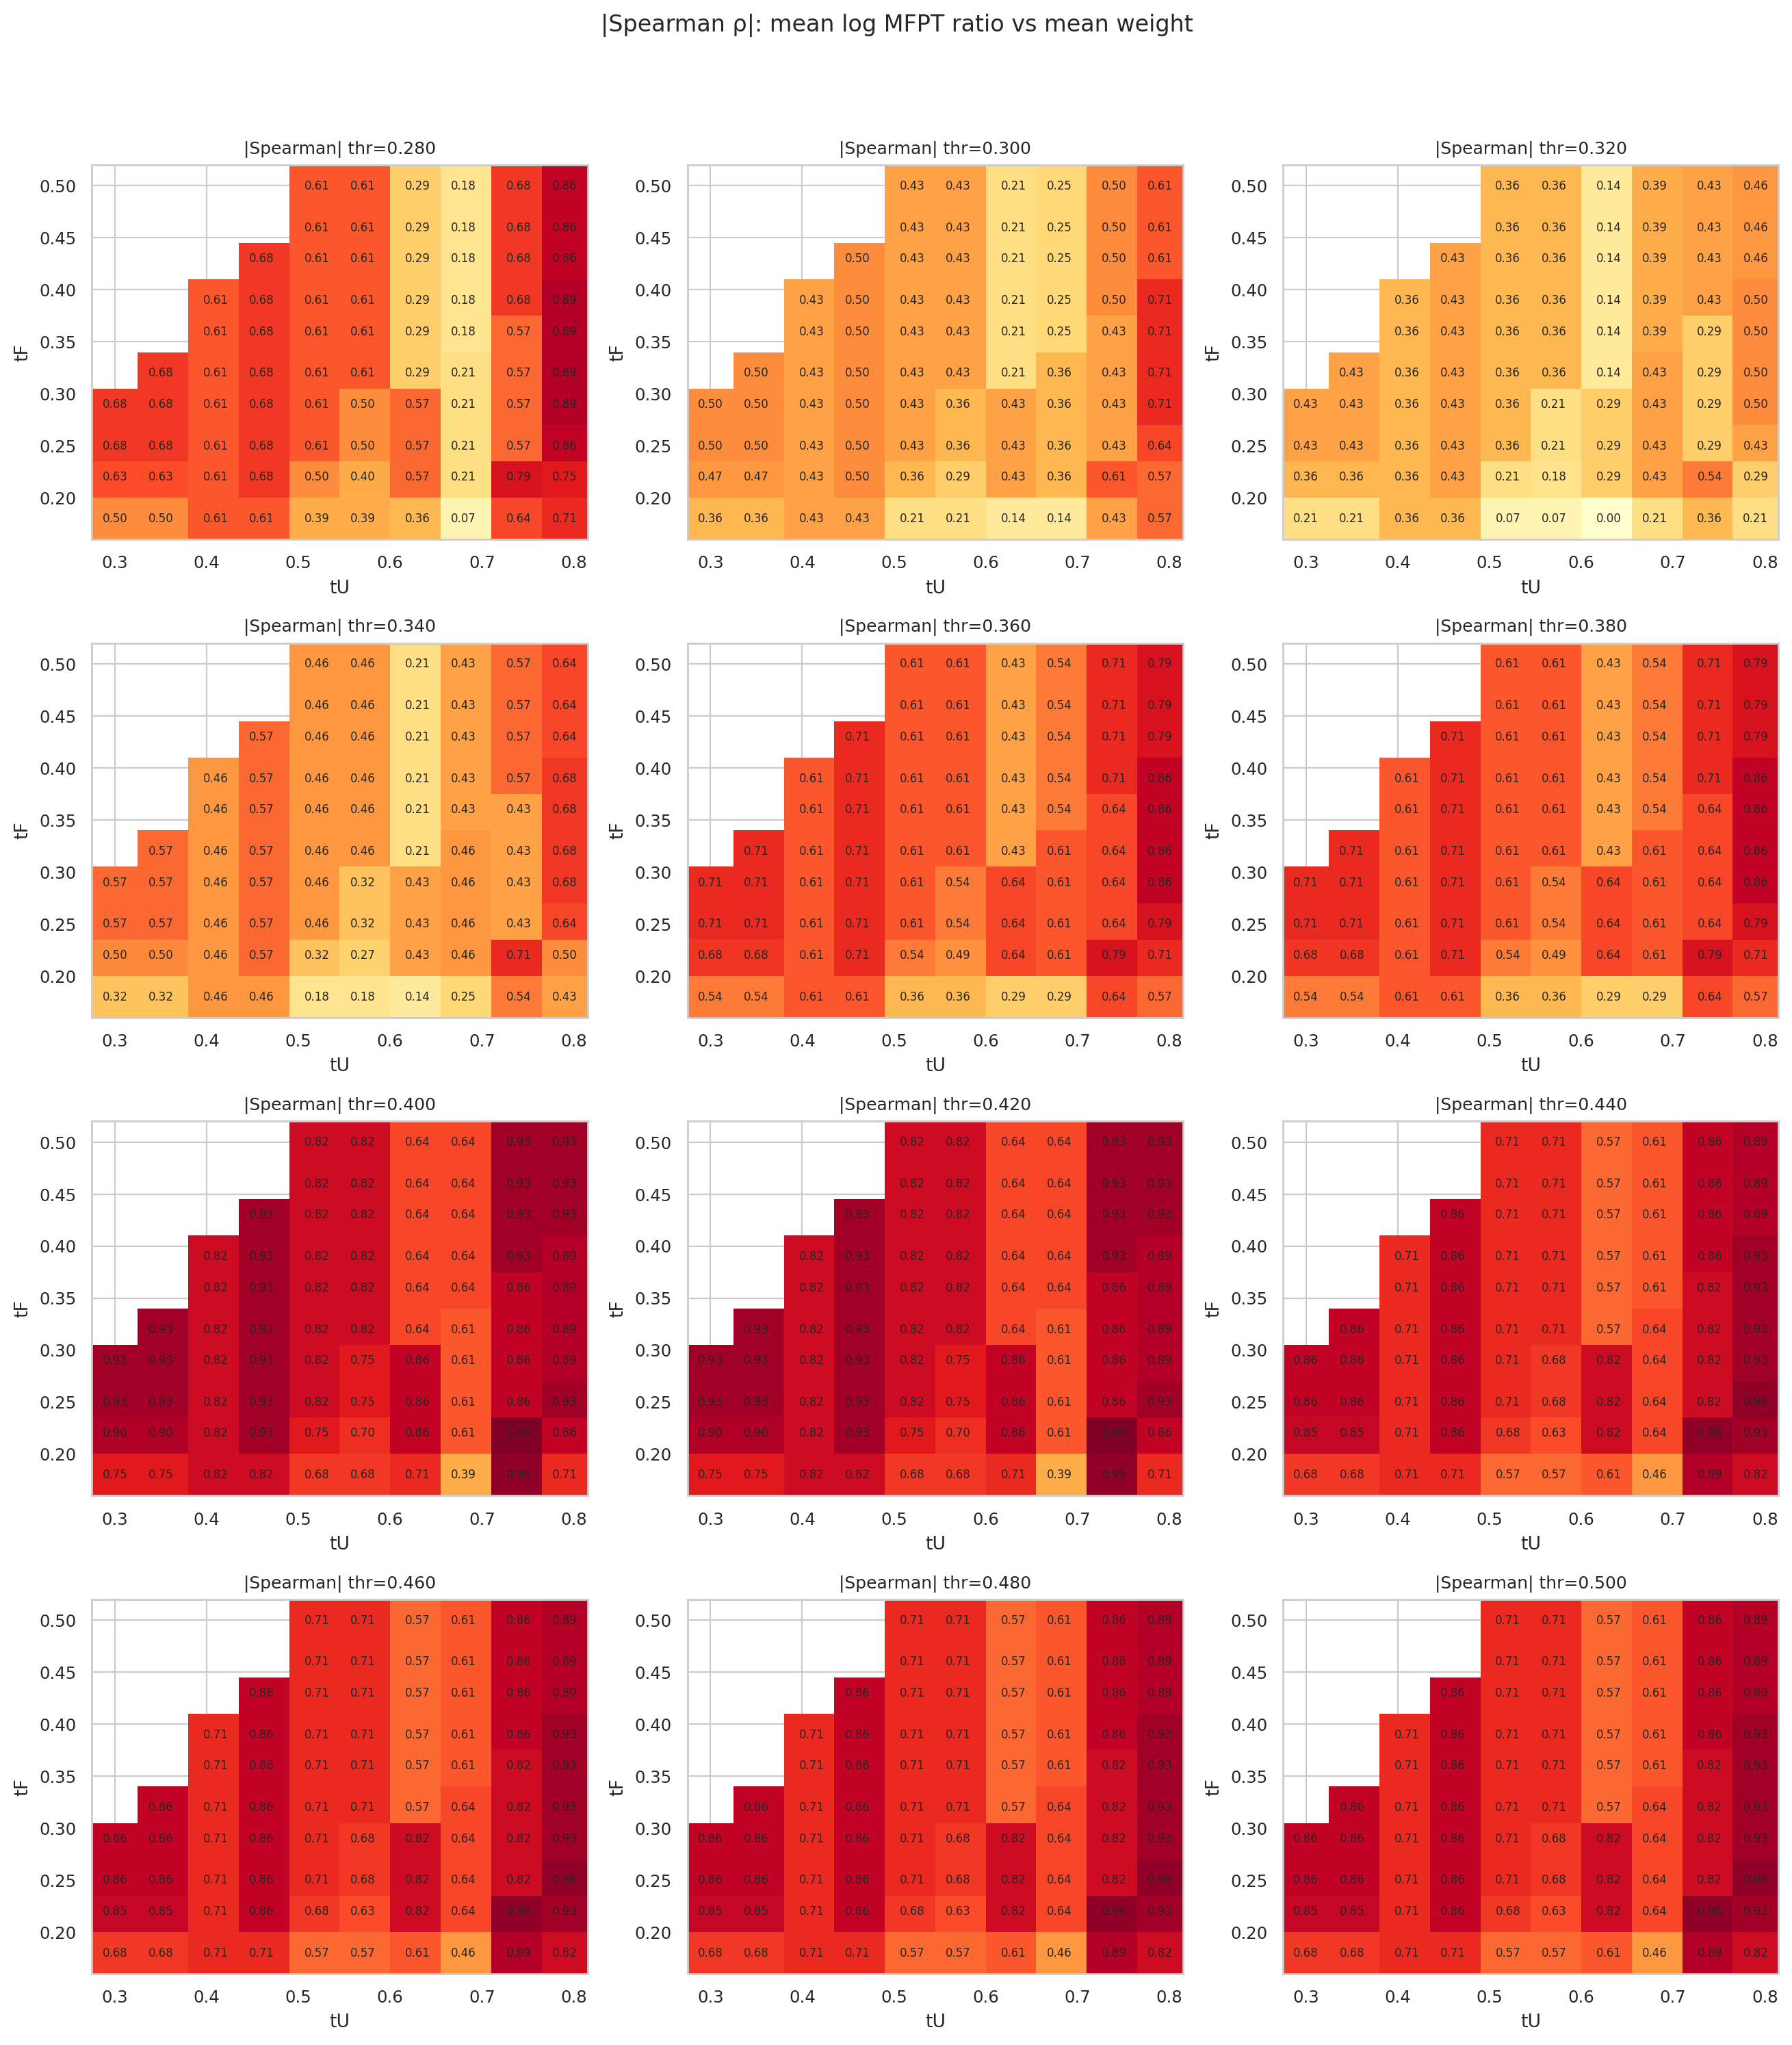

In [73]:
# Heatmaps: per-residue mean log MFPT ratio vs mean residue weight (Spearman)
unique_tf = sorted(lambda_grid['tF'].unique())
unique_tu = sorted(lambda_grid['tU'].unique())

heatmap_ratio_results = []
for thr in mfpt_thresholds:
    rows = []
    for tF in unique_tf:
        for tU in unique_tu:
            sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
            if sub_lam.empty:
                continue
            df_thr = collect_df(
                False,
                mfpt_all,
                mfpt_threshold=float(thr),
                tF=float(tF),
                tU=float(tU),
                lambda_df=sub_lam,
                skip_short=skip_short,
                quiet=True,
            )
            wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
            df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
            df_thr['mut_res_weight'] = df_thr.apply(
                lambda r: r.get(f"res_weight_{int(r['residue_idx'])}") if pd.notna(r['residue_idx']) else np.nan, axis=1
            )
            sub = df_thr.dropna(subset=['mut_res_weight', 'log_mfpt_ratio', 'residue_idx']).copy()
            if sub.empty:
                continue
            mean_df = sub.groupby('residue_idx')[['mut_res_weight', 'log_mfpt_ratio']].mean().reset_index()
            if len(mean_df) < 2:
                continue
            rho = mean_df['mut_res_weight'].corr(mean_df['log_mfpt_ratio'], method='spearman')
            rows.append({'tF': float(tF), 'tU': float(tU), 'val': abs(rho) if pd.notna(rho) else np.nan})
    heatmap_ratio_results.append({'thr': float(thr), 'rows': rows})

ncols = min(3, len(heatmap_ratio_results) if heatmap_ratio_results else 1)
nrows = int(np.ceil(len(heatmap_ratio_results) / ncols)) if heatmap_ratio_results else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
for ax, res in zip(axes.ravel(), heatmap_ratio_results):
    df = pd.DataFrame(res['rows'])
    if df.empty:
        ax.axis('off')
        continue
    plot_heatmap_in_ax(ax, df, 'val', title=f"|Spearman| thr={res['thr']:.3f}", vmin=0, vmax=1, cmap='YlOrRd')
for ax in axes.ravel()[len(heatmap_ratio_results):]:
    ax.axis('off')
fig.suptitle('|Spearman ρ|: mean log MFPT ratio vs mean weight', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



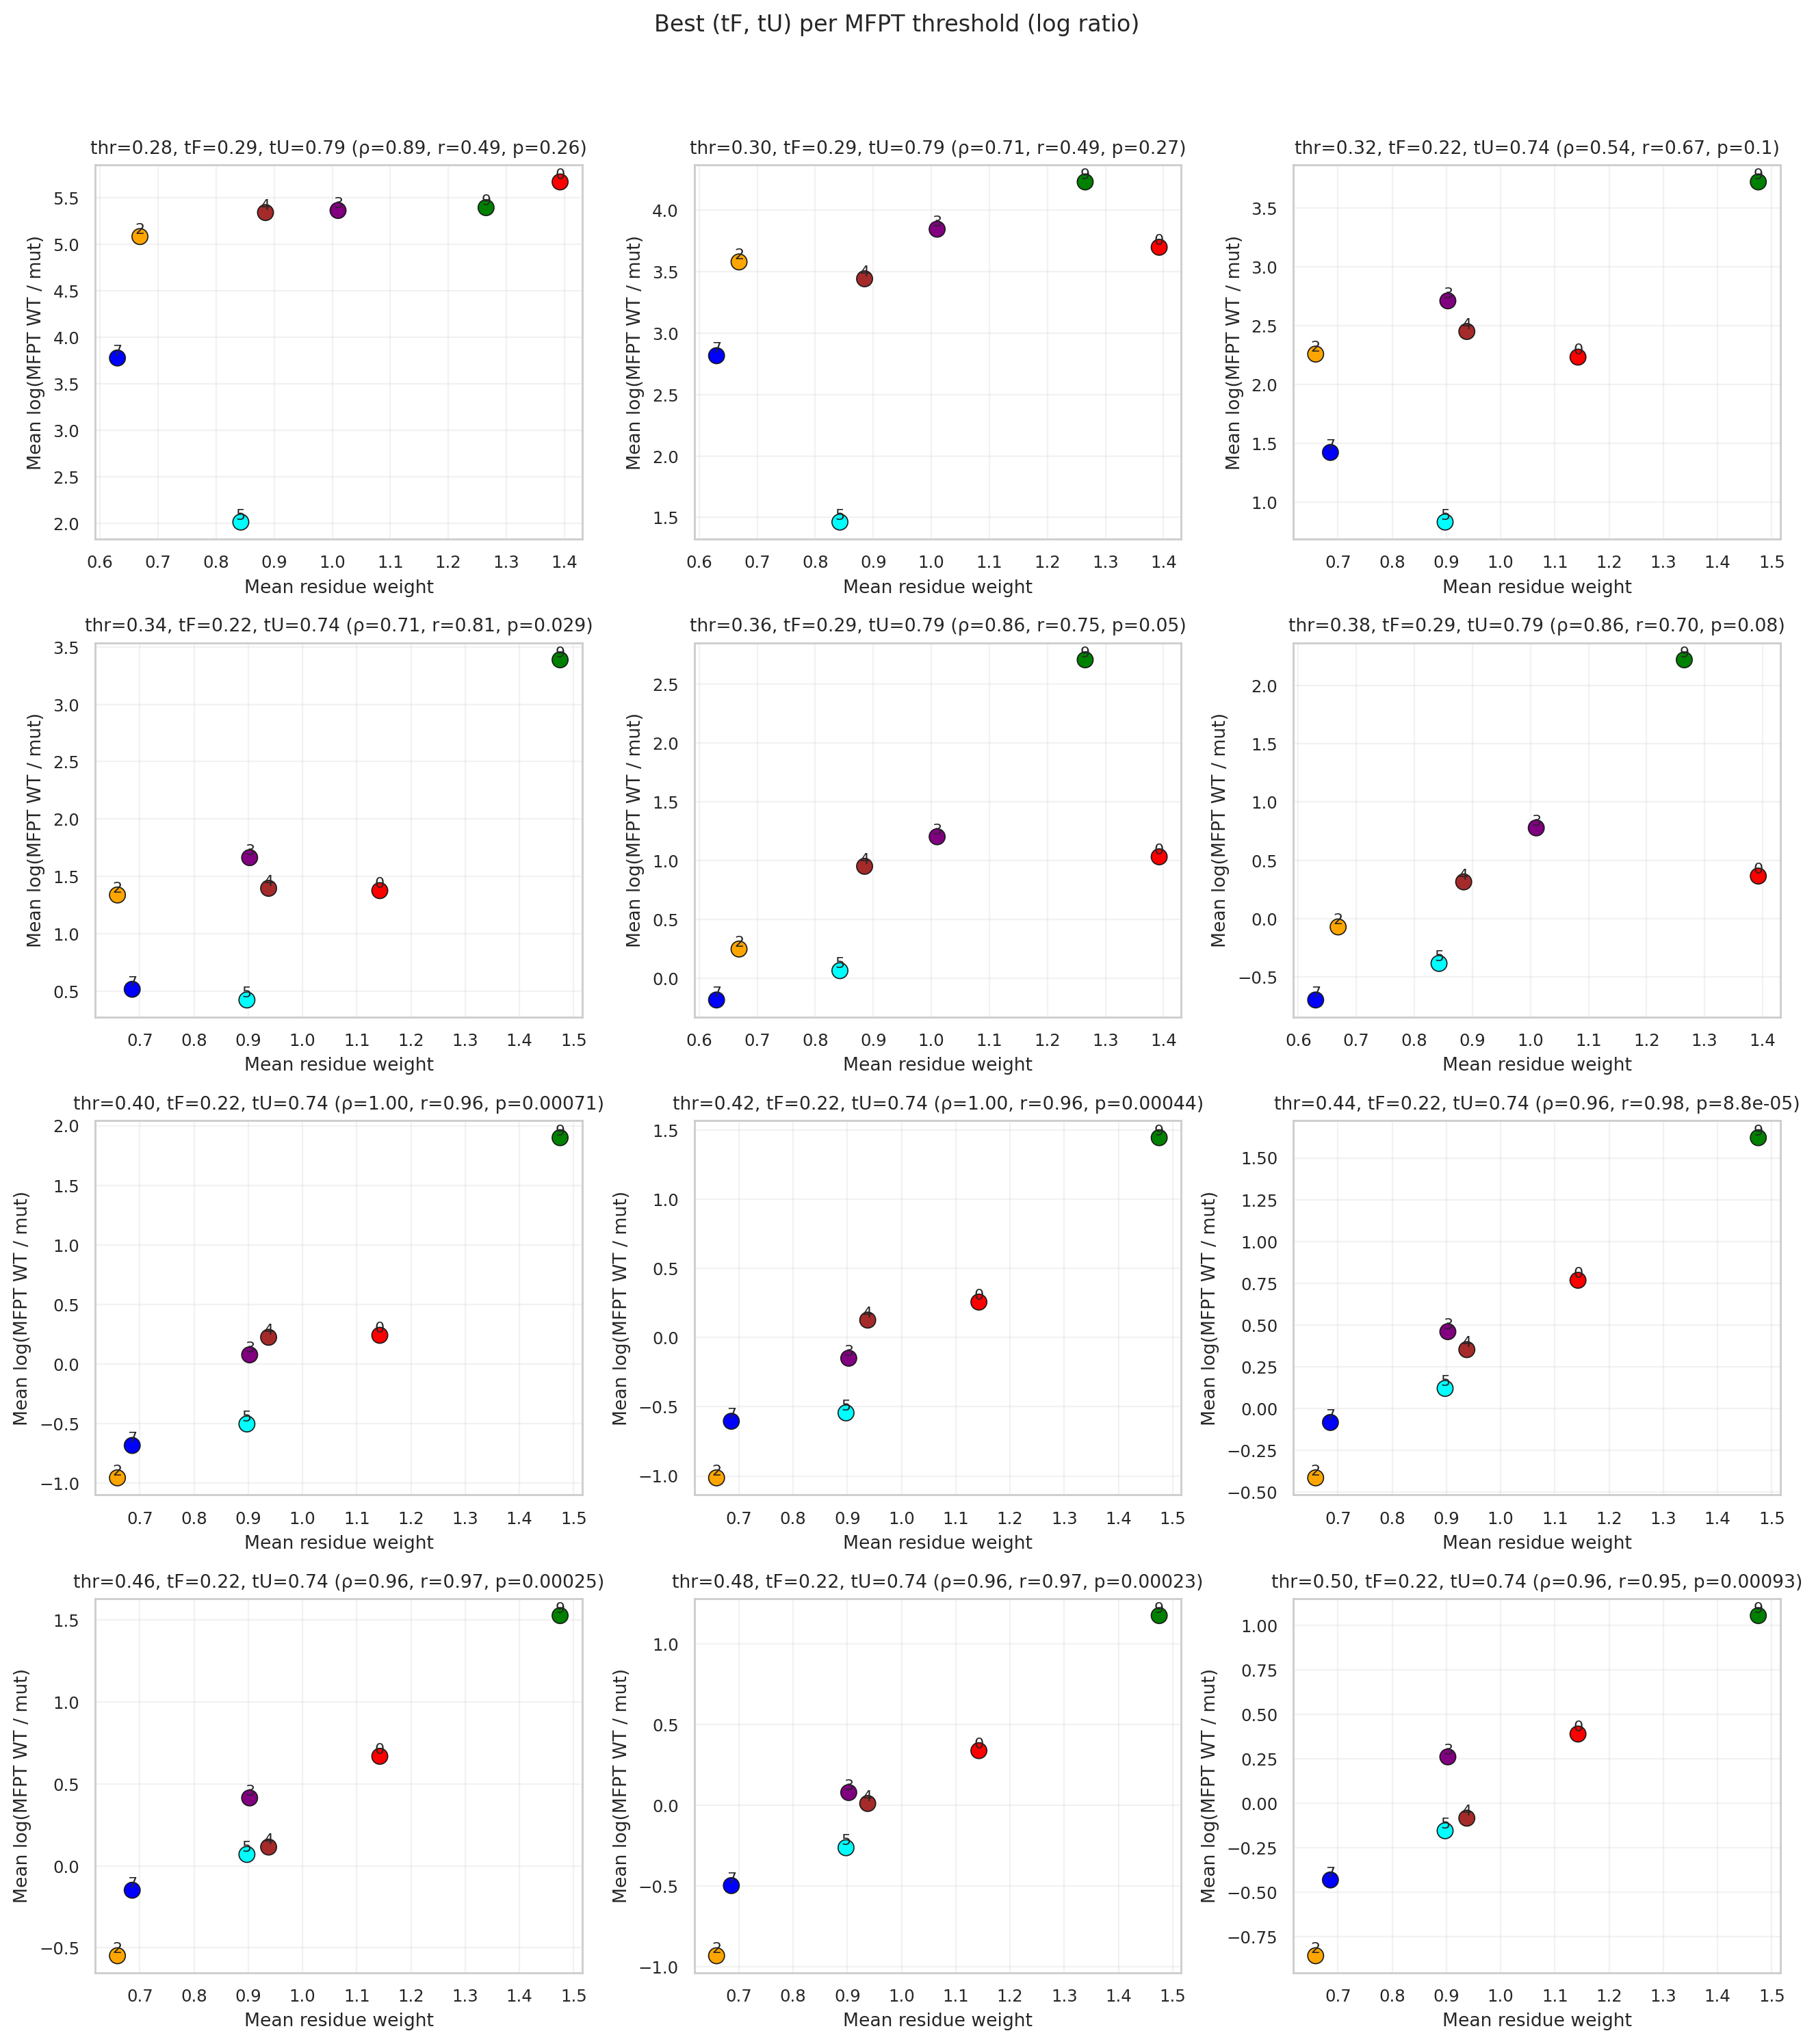

,thr,tF,tU,val
0,0.28,0.29,0.79,0.892857
1,0.30,0.29,0.79,0.714286
2,0.32,0.22,0.74,0.535714
3,0.34,0.22,0.74,0.714286
4,0.36,0.29,0.79,0.857143
5,0.38,0.29,0.79,0.857143
6,0.40,0.22,0.74,1.000000
7,0.42,0.22,0.74,1.000000
8,0.44,0.22,0.74,0.964286
9,0.46,0.22,0.74,0.964286


In [74]:
# Scatter plots at best (tF, tU) per MFPT threshold (log MFPT ratio)
best_rows_ratio = []
for res in heatmap_ratio_results:
    df = pd.DataFrame(res['rows']).dropna(subset=['val'])
    if df.empty:
        continue
    idx = df['val'].idxmax()
    best = df.loc[idx]
    best_rows_ratio.append({'thr': res['thr'], 'tF': best['tF'], 'tU': best['tU'], 'val': best['val']})

ncols = min(3, len(best_rows_ratio) if best_rows_ratio else 1)
nrows = int(np.ceil(len(best_rows_ratio) / ncols)) if best_rows_ratio else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)

for ax, b in zip(axes.ravel(), best_rows_ratio):
    tF = float(b['tF'])
    tU = float(b['tU'])
    thr = float(b['thr'])
    sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
    df_thr = collect_df(
        False,
        mfpt_all,
        mfpt_threshold=float(thr),
        tF=tF,
        tU=tU,
        lambda_df=sub_lam,
        skip_short=skip_short,
        quiet=True,
    )
    wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
    df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
    df_thr['mut_res_weight'] = df_thr.apply(
        lambda r: r.get(f"res_weight_{int(r['residue_idx'])}") if pd.notna(r['residue_idx']) else np.nan, axis=1
    )
    sub = df_thr.dropna(subset=['mut_res_weight', 'log_mfpt_ratio', 'residue_idx']).copy()
    mean_df = sub.groupby('residue_idx')[['mut_res_weight', 'log_mfpt_ratio']].mean().reset_index()
    colors = [res_colors.get(int(i), 'gray') for i in mean_df['residue_idx']]
    ax.scatter(mean_df['mut_res_weight'], mean_df['log_mfpt_ratio'], c=colors, s=70, edgecolor='k', linewidth=0.6)
    for _, row in mean_df.iterrows():
        ax.text(row['mut_res_weight'], row['log_mfpt_ratio'], str(int(row['residue_idx'])), fontsize=8, ha='center', va='bottom')
    rho = mean_df['mut_res_weight'].corr(mean_df['log_mfpt_ratio'], method='spearman')
    from scipy.stats import pearsonr
    r, p = pearsonr(mean_df['mut_res_weight'], mean_df['log_mfpt_ratio'])
    ax.set_title(f"thr={thr:.2f}, tF={tF:.2f}, tU={tU:.2f} (ρ={rho:.2f}, r={r:.2f}, p={p:.2g})")
    ax.set_xlabel('Mean residue weight')
    ax.set_ylabel('Mean log(MFPT WT / mut)')
    ax.grid(True, alpha=0.25)

for ax in axes.ravel()[len(best_rows_ratio):]:
    ax.axis('off')

fig.suptitle('Best (tF, tU) per MFPT threshold (log ratio)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

pd.DataFrame(best_rows_ratio)

